# **Notebook 1: Exploratory Data Analysis (EDA)**


> **Objective:** Perform initial data profiling on the raw data to justify our preprocessing decisions, followed by deep exploratory analysis on `customer_info.csv` and `customer_basket.csv` datasets to uncover actionable business insights and guide Machine Learning feature selection.
The Exploratory Analysis section of this notebook aims at obtaining the most information about our data to better judge what techniques will be required regarding the possibility of missing values and outliers as well as what transformations will be made to the data to improve its usability.


---

## **Table of Contents**
1. [Imports and Data Loading](#1-imports-and-data-loading)
2. [Structural Overview and Datatypes](#2-structural-overview-and-datatypes)
3. [Missing Values Analysis](#3-missing-values-analysis)
4. [Variables Distribution](#4-variables-distribution)
5. [Heat Map and Check Correlations](#5-heat-map-and-check-correlations)
6. [Geo Analysis](#6-geo-analysis)
7. [EDA Summary and Preprocessing Implications](#7-eda-summary-and-preprocessing-implications)

---

## **1. Imports and Data Loading**


In [12]:

%load_ext autoreload
%autoreload 2

import base64
from IPython.display import IFrame, display

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from mapclassify import classify

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


import sys 
sys.path.append("../src") 

from eda import plot_missing_values, plot_distribution, plot_pie_chart, plot_correlation_matrix, map

# Load the RAW datasets
raw_customer = pd.read_csv('../data/customer_info.csv', index_col=0)
raw_basket = pd.read_csv('../data/customer_basket.csv')

print(f"Raw Customer Shape: {raw_customer.shape}")
print(f"Raw Basket Shape: {raw_basket.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Raw Customer Shape: (33038, 24)
Raw Basket Shape: (100000, 3)


## **2. Structural Overview and Datatypes**

> The first step is to get a **good understanding** of the data we're working with. We will start by analyzing more general information.

### **Our Datasets**

In [13]:
display(raw_customer.head())
raw_customer.info()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

In [ ]:
display(raw_basket.head())
raw_basket.info()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


#### **Observations: Introduction and First Rows**

The initial 5 rows of both datasets confirm that the files were imported correctly, with headers and data properly aligned. 

In the `raw_customer` dataset, each row represents a different **customer**, including demographic, behavioral, location and lifetime spending information.

Regarding the `raw_basket` dataset, things are a little bit different. Now, each record represents a **transaction** instead of a customer, which means that each customer can have multiple rows assigned to him/her.

Both datasets share the `customer_id` column, which can later be used to connect transaction-level basket information with the customer segmentation results

### **General Info**

In [41]:
raw_customer.describe().T

,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


In [43]:
raw_customer.describe(include='O').T

,count,unique,top,freq
customer_name,33038,32543,Susan Smith,5
customer_gender,33038,2,female,16577
customer_birthdate,32873,32852,11/03/1998 06:10 PM,2


In [44]:
raw_basket.describe(include='O').T

,count,unique,top,freq
list_of_goods,100000,99784,"['energy bar', 'airpods']",5


#### **Observations:**

The summary of the `raw_customer` dataset allows us to have a complete overview of the dataset where we can verify the presence of possible outliers, impossible values and much more.
We can see enormous values in the variable `lifetime_spend_groceries` with 104670 euros spent which probably indicates **outliers**  and we can also see impossible values on the `percentage_of_products_bought_promotion` column which has a negative minimum value which obviously cannot be possible.

### **Datatypes**

> Identifying these format limitations at this stage provides a clear, structured roadmap for the data cleaning and feature engineering steps that will immediately follow.

In [39]:
raw_customer.dtypes

customer_name                                  str
customer_gender                                str
customer_birthdate                             str
kids_home                                  float64
teens_home                                 float64
number_complaints                          float64
distinct_stores_visited                    float64
lifetime_spend_groceries                   float64
lifetime_spend_electronics                 float64
typical_hour                               float64
lifetime_spend_vegetables                  float64
lifetime_spend_nonalcohol_drinks           float64
lifetime_spend_alcohol_drinks              float64
lifetime_spend_meat                        float64
lifetime_spend_fish                        float64
lifetime_spend_hygiene                     float64
lifetime_spend_videogames                  float64
lifetime_spend_petfood                     float64
lifetime_total_distinct_products           float64
percentage_of_products_bought_p

In [40]:
raw_basket.dtypes

invoice_id       int64
list_of_goods      str
customer_id      int64
dtype: object

#### **Observations: Data Types** 

The initial inspection of the dataset datatypes reveals that it is currently composed entirely of only `float64` and `str` variables.
The numerical columns represent our continuous variables that are ready for mathematical operations. However, some of them would fit even better with another datatype and require scaling later.

Because machine learning algorithms only rely on mathematical calculations, those variables cannot be a part of that process. This will probably involve applying encoding techniques or even completely 'ignoring' them for the usage in our model.

## **3. Missing Value Analysis**

> Moving on to the missing value analysis

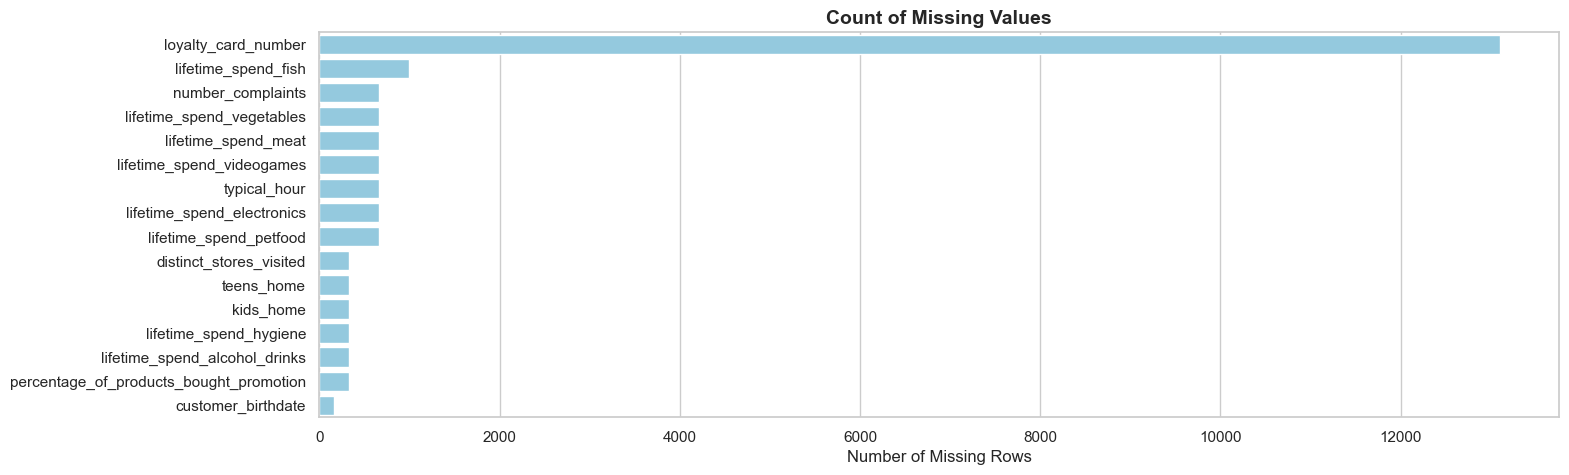

In [38]:
plot_missing_values(raw_customer, 'Count of Missing Values')

#### **Observations:**

This bar chart tells us that 16 of our columns have missing values highlighting the `loyalty_card_number` which has more than 12000 missing values. We will end up dropping that column as it also isn't useful for our models.
We will take care of all those values on the Pre Processing phase.

## **4. Variables Distribution**

### **Distributions**

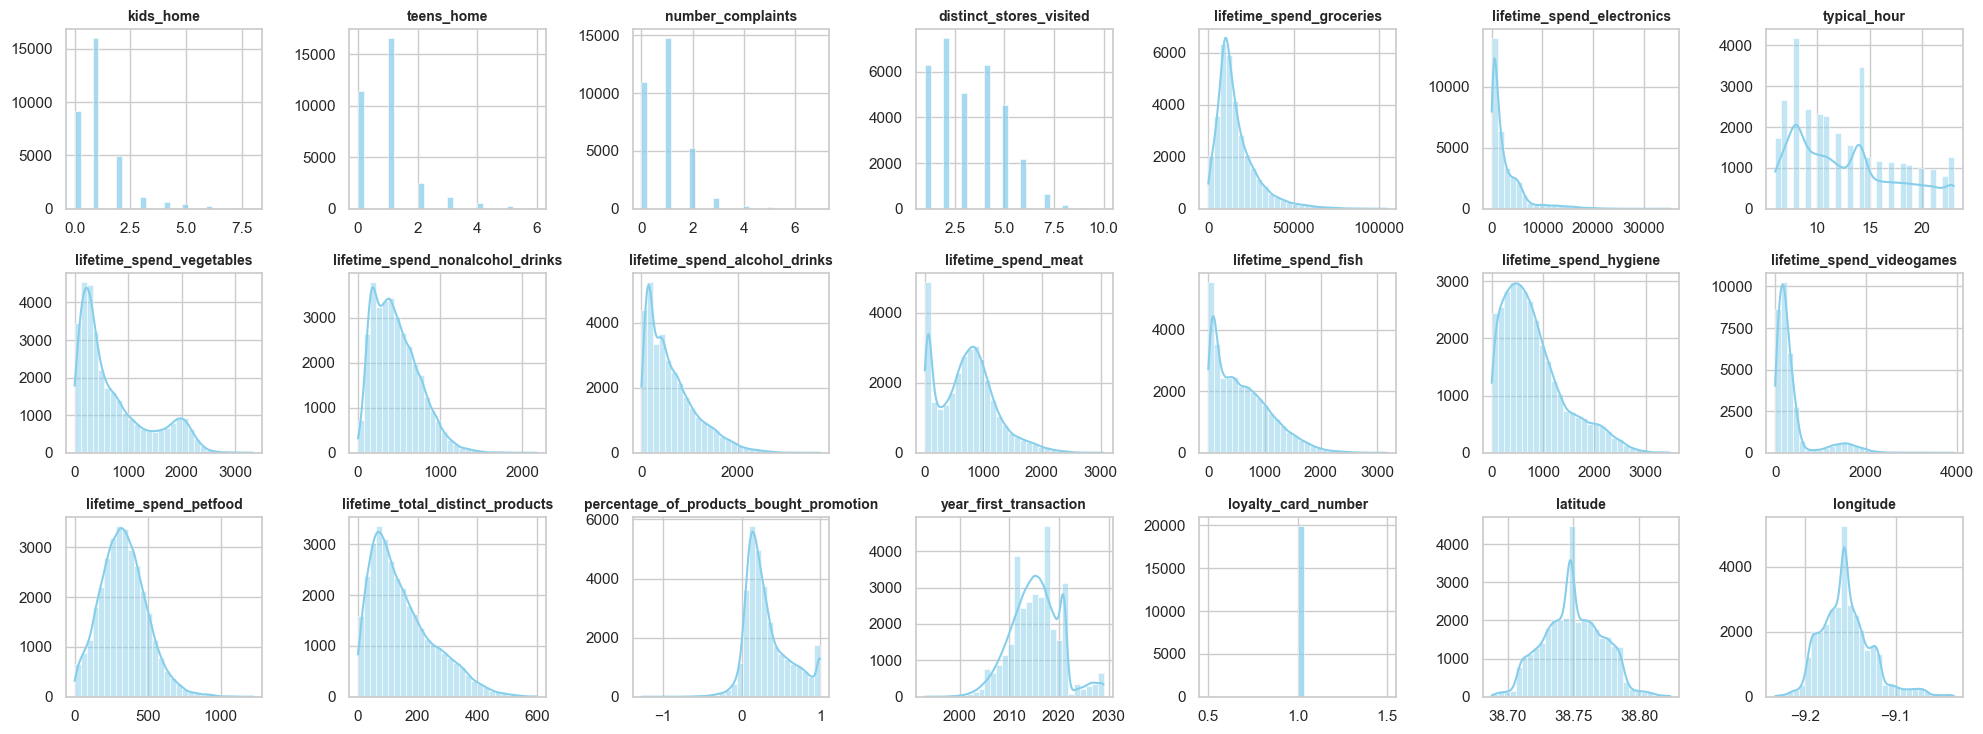

In [45]:
plot_distribution(raw_customer)

#### **Observations: Feature Distributions and Skewness**

The visualizations reveal distinctly different structural patterns across the variables. 
All the `lifetime_spend` variables present a severe right-skewness. They have a massive concentration of record near zero and a long tail of extreme outliers. These, if used directly in modelling, may require transformations such as **logarithmic scaling**. However, for segmentation, relative spending shares may be more informative than raw monetary values.

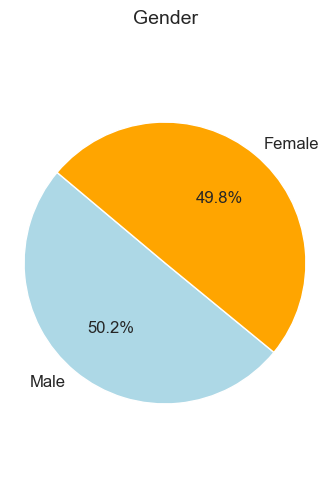

In [53]:
plot_pie_chart(raw_customer, variable='customer_gender', colors=['lightblue', 'orange'], legend=['Male', 'Female'], title_= "Gender")

#### **Observations:**

From the pie chart above we can conclude that our dataset has a nearly **identical distribution** of male and female customers.

## **5. Heat Map and Check Correlations**

> In this section, we will check how our data variables are correlated with each other.

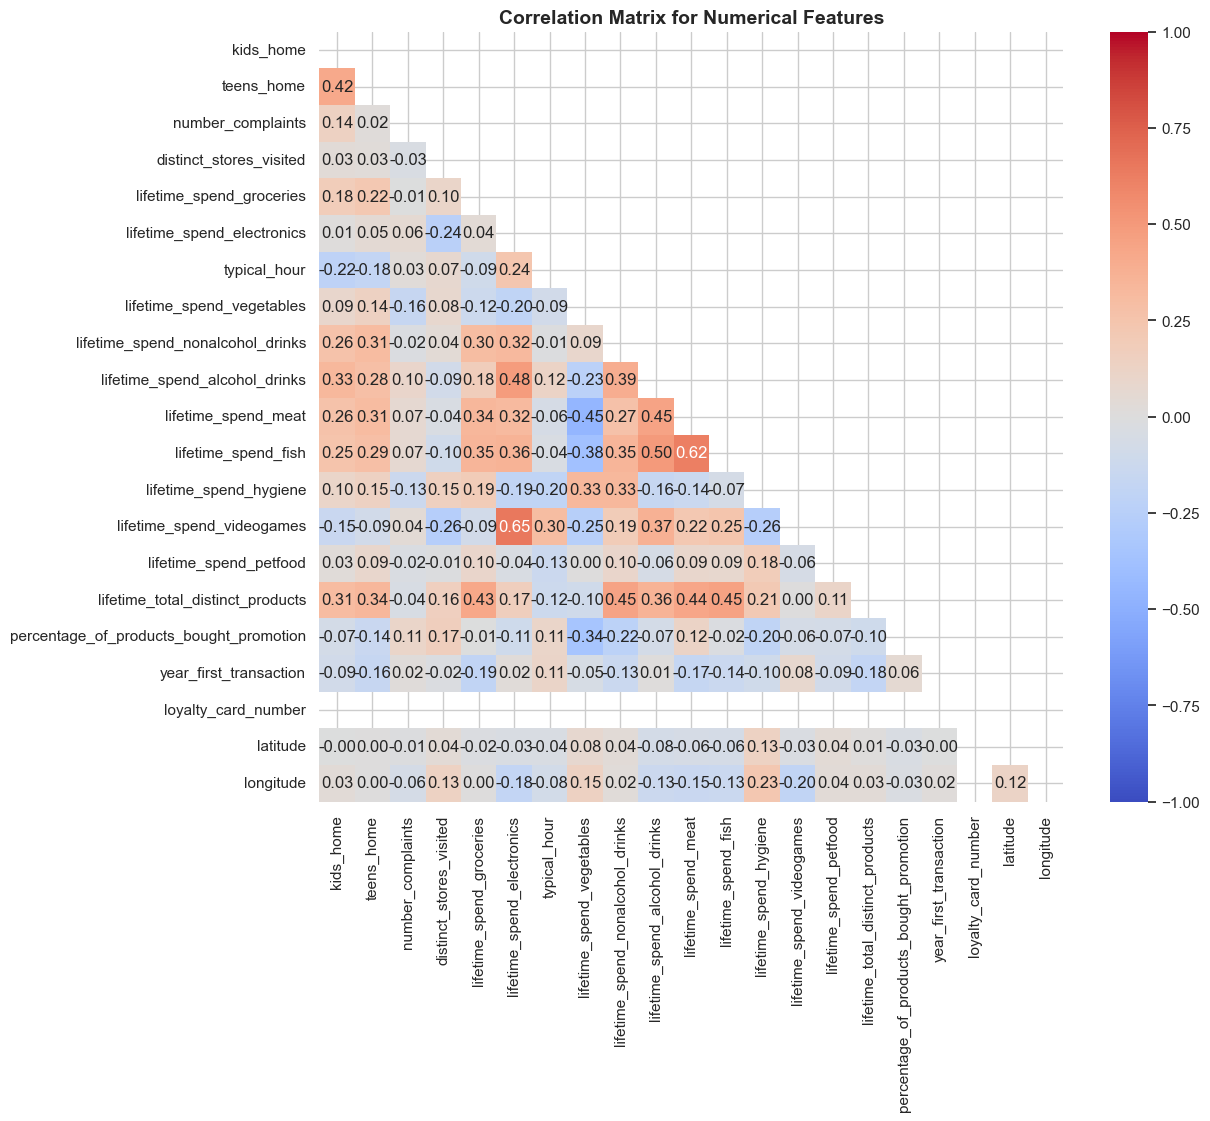

In [75]:
plot_correlation_matrix(raw_customer, title ="Correlation Matrix for Numerical Features")

#### **Observations:**

As we can see above, the highest correlated features are:
- `lifetime_spend_videogames` vs `lifetime_spend_electronics` **(0.65)**
- `lifetime_spend_meat` vs `lifetime_spend_fish` **(0.62)**

This can be explained due to the fact that videogames and electronics in general are linked and, to play videogames one needs, most of the times, some kind of electronic device.
The fish and meat correlation is also predictable because most individuals who eat meat also eat fish if they follow a traditional and regular diet.

Even though they do not have a perfect correlation, there's still correlation and the way we will handle this is by **joining those 2 columns** together creating `lifetime_spend_meat_fish` and `lifetime_spend_videogames_electronics`.


## **6. Geo Analysis**

> Moving on to the geo analysis, we will create a geographical, interactive map by analysing the `latitude`and `longitude` to see where are our clients located and point it out in the map.

In [99]:
data_geo = gpd.GeoDataFrame(
    raw_customer, geometry=gpd.points_from_xy(raw_customer.longitude, raw_customer.latitude),
    crs="EPSG:4326"
)

In [100]:
map(data_geo, sample_size=1200, filename="full_dataset_map.html", random_seed=42)

Saving full dataset map to full_dataset_map.html...
Rendering inline map with a sample of 1200 points...


#### **Observations:**
The map we can see above only has 1200 samples for easier visualization. However, we obviously confirmed that mapping it with all the observations would have similar results and that is why we created a file called `full_dataset_map.html` to prove that.

Besides that, we can see that all the observations are in Lisbon. There are observations that seem to be in the middle of Tejo but that is probably because the latitude and longitude have approximately 1km range.

## **7. EDA Summary and Preprocessing Implications**
